# Loading theory data
This notebook contains test scripts to load theory data. Final figures will still be in the main figure notebook.

In [60]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import h5py
from matplotlib import colors
from matplotlib.lines import Line2D

# DOS data

In [8]:
with h5py.File('../data/fig1/R4G_DOS_data.h5', 'r') as f:
    # Print all keys
    print(list(f.keys()))
    Ds = f['Ds'][:]
    ns = f['ns'][:]
    rhos_per_Auc = f['rhos_per_Auc'][:]
    

['Ds', 'ns', 'rhos_per_Auc']


In [10]:
ns.shape

(10000,)

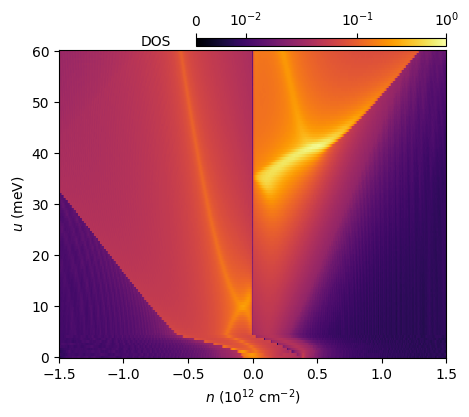

In [115]:
fig = plt.figure(figsize=(5,4))
norm = colors.SymLogNorm(linthresh=0.02, vmin=0, vmax=1)
#norm = colors.Normalize(vmin=0, vmax=1)
plot = plt.pcolormesh(ns, Ds, rhos_per_Auc, cmap="inferno", norm=norm)
ax = plt.gca()
ax.set_xlabel(r'$n$ ($10^{12}$ $\mathrm{cm^{-2}}$)')
ax.set_ylabel(r'$u$ (meV)')

pos = ax.get_position()
cb_width = 0.5  
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.02])

cb = plt.colorbar(plot, cax=cax, ticks=[0, 1e-2, 1e-1, 1], \
                  orientation='horizontal')
#cb.ax.set_xlabel(r'DOS', labelpad=-30, x=-0.10)
cb.ax.annotate('DOS', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')  

#ax.set_xlim(0, 1.5)
#ax.set_ylim(30, 60)

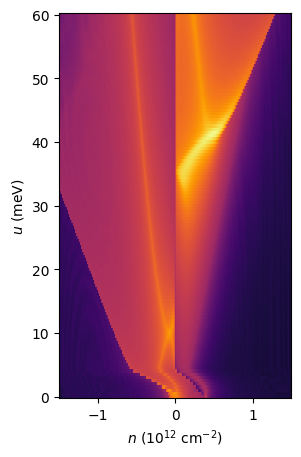

In [111]:
rfig = plt.figure(figsize=(3,5))
norm = colors.SymLogNorm(linthresh=0.03, vmin=0, vmax=1)
#norm = colors.Normalize(vmin=0, vmax=1)
plot = plt.pcolormesh(ns, Ds, rhos_per_Auc, cmap="inferno", norm=norm)
ax = plt.gca()
ax.set_xlabel(r'$n$ ($10^{12}$ $\mathrm{cm^{-2}}$)')
ax.set_ylabel(r'$u$ (meV)')

pos = ax.get_position()
cb_width = 0.5  
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.02])

cb = plt.colorbar(plot, cax=cax, ticks=[0, 1e-2, 1e-1, 1], \
                  orientation='horizontal')
cb.ax.set_xlabel(r'DOS', labelpad=-30, x=-0.10)
cb.ax.annotate('DOS', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')  

#ax.set_xlim(0.0, 1.5)
#ax.set_ylim(0, 55)

# R4G bandstructure DOS data

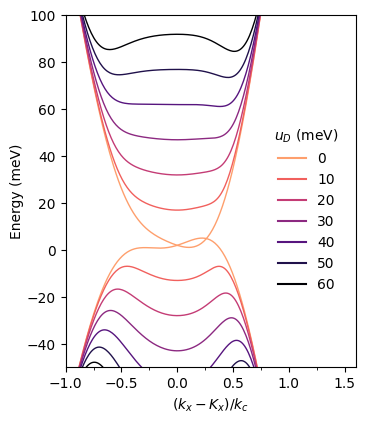

In [78]:
with h5py.File("../data/fig1/R4G_bandstructure_DOS_data.h5", "r") as f:
    uD_meV       = f["uD_meV"][:]
    ks_over_kc   = f["ks_over_kc"][:]
    # HDF5 stores Julia column-major arrays such that h5py reads them
    # back with reversed axes. The Julia exporter wrote
    #     Es_eV       (n_D, n_bands, Nk_line)
    #     dos_*       (n_D, Ndos_max)
    # so transpose on read to recover the documented shapes.
    Es_eV        = f["Es_eV"][:].T            # (n_D, n_bands, Nk)
    dos_rho      = f["dos_rho_per_Auc"][:].T  # (n_D, Ndos), NaN-padded
    dos_mu_eV    = f["dos_mu_eV"][:].T
    meVscale     = float(f["meVscale"][()])
    Mlayers      = int(f["Mlayers"][()])

    n_D, n_bands, _ = Es_eV.shape
    pals = plt.get_cmap("magma_r")(np.linspace(0.2, 1, n_D))

    ymin, ymax = -50, 100   # meV — matches the Julia figure
    fig, axs = plt.subplots(
            1,1,
            figsize=(3.375, 4),
        )

    # ── Left panel: bands along k_x through K ────────────────────────────
    ax = axs
    for d in range(n_D):
        for b in range(n_bands):
            ax.plot(ks_over_kc, meVscale * Es_eV[d, b, :],
                    color=pals[d], lw=1.0)
    #ax.set_ylim(ymin, ymax)
    ax.set_ylabel("Energy (meV)", labelpad=2)
    ax.set_xlabel(r"$(k_x - K_x)/k_c$")
    #ax.set_yticks(np.arange(ymin, ymax + 1, 5), minor=False)
    ax.set_xticks(np.arange(-1.5, 1.51, 0.25), minor=True)
    ax.set_xlim(-1.0, 1.6)

    legend_handles = [
        Line2D([0], [0], color=pals[i], lw=1.5,
               label=f"{int(round(uD_meV[d]))}")
        for i, d in enumerate(range(n_D))
    ]

    ax.set_ylim(ymin, ymax)
    ax.legend(
            handles=legend_handles,
            title=r"$u_D$ (meV)",
            loc=(0.7, 0.2),
            frameon=False,
    )

    fig.subplots_adjust(wspace=0.0, left=0.13, right=0.99,
                        top=0.98, bottom=0.1)
 

# SCHF

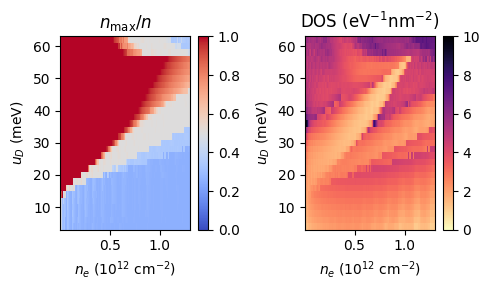

In [87]:

def main(pd):
  temp=np.load(pd['fname'],allow_pickle=True)
  
  
  data=temp['collect_data'] #[iU,iepsr,ine,occ or unocc]
  

  Us=np.array(temp['Us']).astype(float)
  epsrs=np.array(temp['epsrs']).astype(float)
  nelist=np.array(temp['nelist']).astype(float)
  numne=len(nelist)
  nU=len(Us)
  nepsr=len(epsrs)
  XX,YY=np.meshgrid(nelist,Us,indexing='ij')
  YY*=1e3
  XX/=1e16
  
  DOS=np.load(pd['DOSfname'])['DOS_data']

  # print(data)
  for iepsr,epsr in enumerate(epsrs):
    if iepsr in [2]: 
      
      DOSproc=np.zeros((numne,nU))
      fracproc=np.zeros((numne,nU))
      
      for iU in range(nU):
        for ine in range(numne):
          #only not-FP
          if np.isnan(data[iU,iepsr,ine,0]) and not np.isnan(data[iU,iepsr,ine,1]):
            fracproc[ine,iU]=data[iU,iepsr,ine,2]/np.sum(data[iU,iepsr,ine,2:6])
            DOSproc[ine,iU]=DOS[iU,iepsr,ine,1]
          #only FP
          elif not np.isnan(data[iU,iepsr,ine,0]) and np.isnan(data[iU,iepsr,ine,1]):
            fracproc[ine,iU]=1
            DOSproc[ine,iU]=DOS[iU,iepsr,ine,0]
          #FP lower energy
          elif data[iU,iepsr,ine,1]>data[iU,iepsr,ine,0]:
            fracproc[ine,iU]=1
            DOSproc[ine,iU]=DOS[iU,iepsr,ine,0]  
            #FP lower energy
          elif data[iU,iepsr,ine,1]<data[iU,iepsr,ine,0]:
            fracproc[ine,iU]=data[iU,iepsr,ine,2]/np.sum(data[iU,iepsr,ine,2:6])
            DOSproc[ine,iU]=DOS[iU,iepsr,ine,1]
          else:
            print("ASEF")


            
      """
      PLOTTING STARTS HERE
      """
      fig,axs=plt.subplots(1,2,figsize=(5,3))
      
      #plot nmax/n
      ccc=axs[0].pcolormesh(XX,YY,fracproc,cmap='coolwarm',shading='nearest',vmin=0,vmax=1)
      plt.colorbar(ccc,ax=axs[0])
      axs[0].set_title(r"$n_\mathrm{max}/n$")
      
      #plot DOS
      ccc=axs[1].pcolormesh(XX,YY,DOSproc/1e18,cmap='magma_r',shading='nearest',vmin=0,
                            vmax=10
                            )
      plt.colorbar(ccc,ax=axs[1])
      axs[1].set_title(r"DOS (eV$^{-1}\mathrm{nm}^{-2}$)")  
      
      #axis labels
      for iax in range(2):
        axs[iax].set_xlabel(r"$n_e$ ($10^{12}$ cm$^{-2}$)")
        axs[iax].set_ylabel(r"$u_D$ (meV)")
      
      
      plt.tight_layout()
      plt.savefig(r"draft_fig_epsr%d.png"%epsr,dpi=200)
      
      



pd={}

pd['fname']='../data/fig1/collect_data.npz'
pd['DOSfname']='../data/fig1/DOS_data.npz'

main(pd)